# Phase D: Leakage-Free Accuracy Optimization and Final Export

This notebook preserves the V7 TSFEL + HistGradientBoosting pipeline while evaluating controlled upgrades. Model selection uses nested LOSO on S1, S2, S3, and S5 only. S4 is excluded until the method is locked. Every held-out subject is inferred with continuous, fixed-stride windows created without labels.

In [1]:
from pathlib import Path
import json, sys, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

ROOT = Path.cwd()
PHASE_DIR = ROOT / 'artifacts' / 'phase_d'
OUTPUT_DIR = ROOT / 'outputs' / 'phase_d'
DEV_SUBJECTS = [1, 2, 3, 5]
ALL_SUBJECTS = [1, 2, 3, 4, 5]
print('Python:', sys.executable)
print('Artifacts:', PHASE_DIR.resolve())

Python: python
Artifacts: .\artifacts\phase_d


## 1. Protocol and Self-Critique

- Training windows may use labels for majority-label assignment and ambiguous-window rejection.
- Validation and held-out inference windows must never use labels for inclusion, exclusion, boundaries, or overlap.
- Hyperparameters, binary-gate strength, and temporal-decoder strength are selected inside nested LOSO.
- S4 labels are secondary evaluation data and never affect the four-subject lock.
- Accuracy is optimized only among candidates that preserve abnormal F1 and hard-subject performance.

In [2]:
cache_audit = []
for subject in ALL_SUBJECTS:
    path = PHASE_DIR / 'c_inference_cache' / f'c_unlabeled_stride75_subject_{subject}.joblib'
    payload = joblib.load(path)
    windows = payload['windows']
    cache_audit.append({
        'subject': subject,
        'windows': len(windows.x),
        'signature_labeled': payload['signature'].get('labeled'),
        'non_null_window_labels': int(windows.y.notna().sum()),
        'feature_count': windows.x.shape[1],
    })
cache_audit = pd.DataFrame(cache_audit)
display(cache_audit)
assert cache_audit['signature_labeled'].eq(False).all()
assert cache_audit['non_null_window_labels'].eq(0).all()

,subject,windows,signature_labeled,non_null_window_labels,feature_count
0,1,1019,False,0,2635
1,2,995,False,0,2635
2,3,1574,False,0,2635
3,4,1572,False,0,2635
4,5,1013,False,0,2635


## 2. V7-Compatible Preprocessing and Feature Stages

The retained core is pose cleaning, participant-local normalization, fixed temporal windows, TSFEL statistics, handcrafted geometry/motion features, training-only feature selection, and HistGradientBoosting. D0 is the corrected C baseline; D1 regularizes feature capacity and the classifier; D2 tests compact multi-scale geometry; D3 adds nested temporal decoding; D4 tests a shallow temporal convolutional network.

In [3]:
stages = pd.DataFrame([
    ['D0u', 'V7-compatible C features', 'HistGradientBoosting baseline', 'Unlabeled stride-75'],
    ['D1u', 'C + training-only compact selection', 'Regularized HistGradientBoosting', 'Unlabeled stride-75'],
    ['D2', 'Compact geometry at 60/150/300 frames', 'Nested scale/model fusion', 'Unlabeled continuous'],
    ['D3u', 'D1u features', 'Optional soft gate + nested Viterbi', 'Unlabeled stride-75'],
    ['D4', 'Normalized pose streams', 'Shallow multi-stream TCN', 'Unlabeled continuous'],
], columns=['candidate', 'features', 'model', 'held_out_inference'])
display(stages)

,candidate,features,model,held_out_inference
0,D0u,V7-compatible C features,HistGradientBoosting baseline,Unlabeled stride-75
1,D1u,C + training-only compact selection,Regularized HistGradientBoosting,Unlabeled stride-75
2,D2,Compact geometry at 60/150/300 frames,Nested scale/model fusion,Unlabeled continuous
3,D3u,D1u features,Optional soft gate + nested Viterbi,Unlabeled stride-75
4,D4,Normalized pose streams,Shallow multi-stream TCN,Unlabeled continuous


In [4]:
def show_fold(prefix, subject, title):
    metrics = pd.read_csv(PHASE_DIR / f'{prefix}_fold_metrics.csv')
    row = metrics.loc[metrics['held_out_subject'].eq(subject)]
    display(row)
    confusion = pd.read_csv(PHASE_DIR / f'{prefix}_confusion_subject_{subject}.csv', index_col=0)
    plt.figure(figsize=(9, 7))
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.tight_layout()
    plt.show()

def show_subject_progress(subject):
    rows = []
    for prefix, name in [('d0u', 'D0u'), ('d1u', 'D1u'), ('d2', 'D2'), ('d3u', 'D3u'), ('d4', 'D4')]:
        metrics = pd.read_csv(PHASE_DIR / f'{prefix}_fold_metrics.csv')
        row = metrics.loc[metrics['held_out_subject'].eq(subject)].iloc[0].to_dict()
        row['candidate'] = name
        rows.append(row)
    display(pd.DataFrame(rows).set_index('candidate'))

## 3. Corrected Baseline Before the Accuracy Upgrade

### D0u Baseline - Held-Out S1

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,0.574593,0.494594,0.793919,0.982153,0.666232


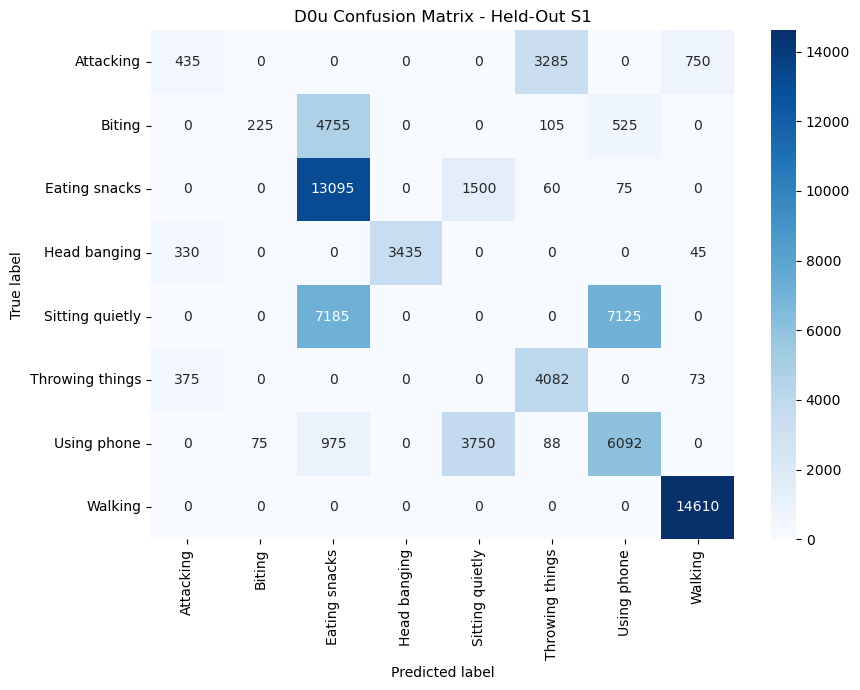

In [5]:
show_fold('d0u', 1, 'D0u Confusion Matrix - Held-Out S1')

### D0u Baseline - Held-Out S2

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
1,2,0.719368,0.642027,0.767282,0.909887,0.663321


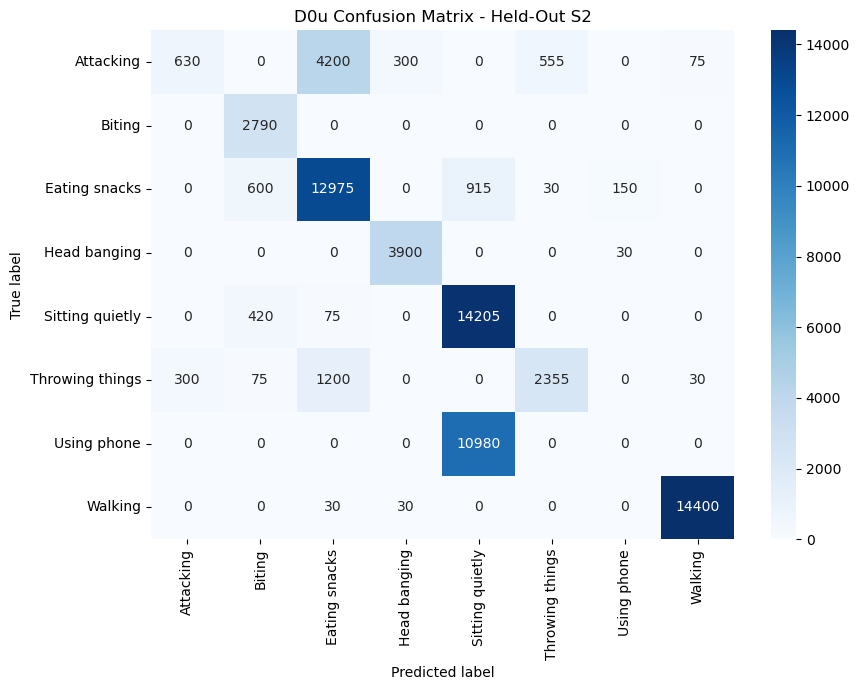

In [6]:
show_fold('d0u', 2, 'D0u Confusion Matrix - Held-Out S2')

### D0u Baseline - Held-Out S3

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
2,3,0.428149,0.407706,0.525635,0.41023,0.73139


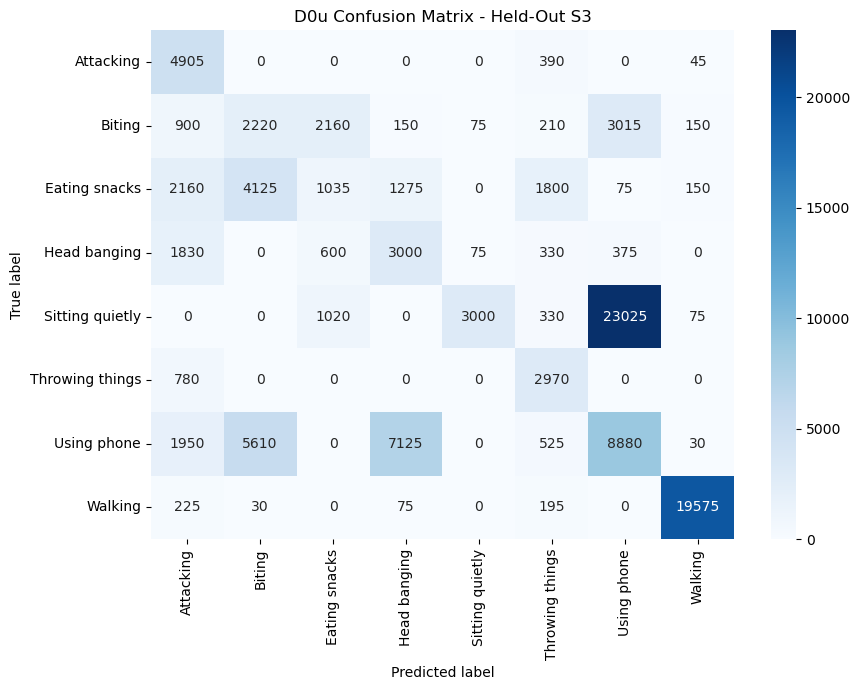

In [7]:
show_fold('d0u', 3, 'D0u Confusion Matrix - Held-Out S3')

### D0u Baseline - Held-Out S5

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
3,5,0.610972,0.644757,0.907377,0.993122,0.835262


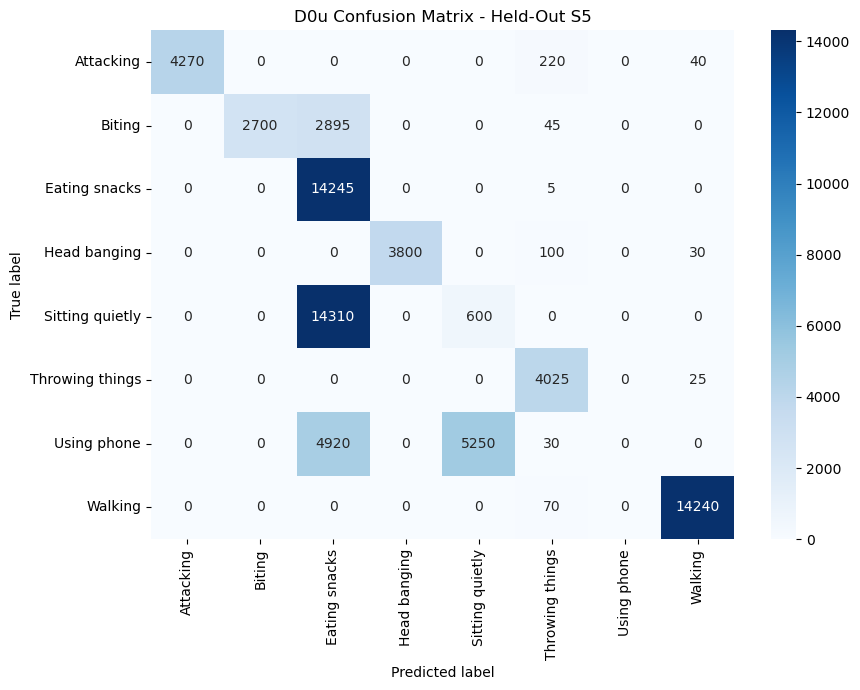

In [8]:
show_fold('d0u', 5, 'D0u Confusion Matrix - Held-Out S5')

## 4. Controlled Feature and Model Upgrades

### Upgrade Comparison - Held-Out S1

In [9]:
show_subject_progress(1)

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
candidate,,,,,,
D0u,1.0,0.574593,0.494594,0.793919,0.982153,0.666232
D1u,1.0,0.569227,0.479363,0.772409,0.985017,0.635288
D2,1.0,0.609870,0.568816,0.750000,0.674026,0.845277
D3u,1.0,0.566352,0.469187,0.778456,0.985204,0.643431
D4,1.0,0.587296,0.571805,0.653442,0.667214,0.640228


### Upgrade Comparison - Held-Out S2

In [10]:
show_subject_progress(2)

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
candidate,,,,,,
D0u,2.0,0.719368,0.642027,0.767282,0.909887,0.663321
D1u,2.0,0.736842,0.664352,0.859113,0.933619,0.795620
D2,2.0,0.742316,0.666489,0.907749,0.917910,0.897810
D3u,2.0,0.737263,0.662417,0.856433,0.940022,0.786496
D4,2.0,0.520000,0.480547,0.497143,0.408451,0.635036


### Upgrade Comparison - Held-Out S3

In [11]:
show_subject_progress(3)

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
candidate,,,,,,
D0u,3.0,0.428149,0.407706,0.525635,0.410230,0.731390
D1u,3.0,0.433643,0.415976,0.500341,0.394765,0.683002
D2,3.0,0.369682,0.327197,0.501031,0.397310,0.678040
D3u,3.0,0.437870,0.421182,0.501480,0.396186,0.683002
D4,3.0,0.384615,0.356275,0.548643,0.413468,0.815136


### Upgrade Comparison - Held-Out S5

In [12]:
show_subject_progress(5)

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
candidate,,,,,,
D0u,5.0,0.610972,0.644757,0.907377,0.993122,0.835262
D1u,5.0,0.664230,0.701723,0.870416,0.977351,0.784573
D2,5.0,0.568017,0.554432,0.793309,0.953228,0.679339
D3u,5.0,0.665622,0.702585,0.865942,0.957916,0.790083
D4,5.0,0.611807,0.643410,0.930178,0.990050,0.877135


## 5. Final Development-Set Comparison and Lock

In [13]:
comparison = json.loads((PHASE_DIR / 'final_comparison.json').read_text())
comparison_table = pd.DataFrame(comparison['candidates']).T
display(comparison_table[['eligible', 'pooled_accuracy', 'pooled_macro_f1', 'pooled_abnormal_f1', 'worst_subject_accuracy', 'eligibility_reasons']])
print('Locked winner:', comparison['winner'])
display(pd.DataFrame([comparison['selection_protocol']]))

,eligible,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject_accuracy,eligibility_reasons
D0u-C-unlabeled-inference,True,0.566335,0.559208,0.700078,0.428149,[]
D1u-regularized-C-unlabeled-inference,True,0.58265,0.566973,0.696454,0.433643,[]
D2-multiscale-geometry,False,0.550532,0.527853,0.692443,0.369682,"[abnormal_f1_below_tolerance, worst_subject_ac..."
D3u-D1u-soft-gate-viterbi,True,0.583797,0.568424,0.697074,0.43787,[]
D4-shallow-multistream-TCN,False,0.510995,0.518287,0.628348,0.384615,"[abnormal_f1_below_tolerance, worst_subject_ac..."


Locked winner: D3u-D1u-soft-gate-viterbi


,development_subjects,held_out_windowing,abnormal_f1_tolerance,maximum_per_subject_accuracy_loss,ranking,s4_used_for_selection
0,"[1, 2, 3, 5]",unlabeled_continuous,0.005,0.05,"[pooled_accuracy, worst_subject_accuracy, pool...",False


In [14]:
locked = joblib.load(PHASE_DIR / 'locked_phase_d_subjects_1_2_3_5.joblib')
display(pd.DataFrame([{
    'locked_candidate': locked['locked_candidate'],
    'development_subjects': locked['development_subjects'],
    'selected_candidate_index': locked.get('selected_candidate_index'),
    'feature_count': len(locked['model'].selector.selected_columns) if hasattr(locked['model'], 'selector') else None,
    'transition_strength': locked.get('decoder', {}).get('transition_strength', 0.0),
}]))

,locked_candidate,development_subjects,selected_candidate_index,feature_count,transition_strength
0,D3u-D1u-soft-gate-viterbi,"[1, 2, 3, 5]",15,256,2.0


## 6. S4 Prediction and Secondary Evaluation

,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall,classification_report,error_rate,evaluated_frames,non_target_frames_excluded,s4_status
0,0.799201,0.840994,0.867879,0.792913,0.958501,{'Attacking': {'precision': 0.8615384615384616...,0.200799,108840,9081,secondary_non_blind_evaluation


,true_label,predicted_label,row_error_rate,frames
0,Sitting quietly,Using phone,0.340000,8160
1,Using phone,Eating snacks,0.138924,3255
2,Using phone,Biting,0.128041,3000
3,Eating snacks,Using phone,0.099681,1875
4,Eating snacks,Biting,0.095694,1800
5,Using phone,Sitting quietly,0.067862,1590
6,Head banging,Walking,0.051020,300
7,Throwing things,Walking,0.044715,165
8,Biting,Eating snacks,0.037102,315
9,Attacking,Walking,0.034483,150


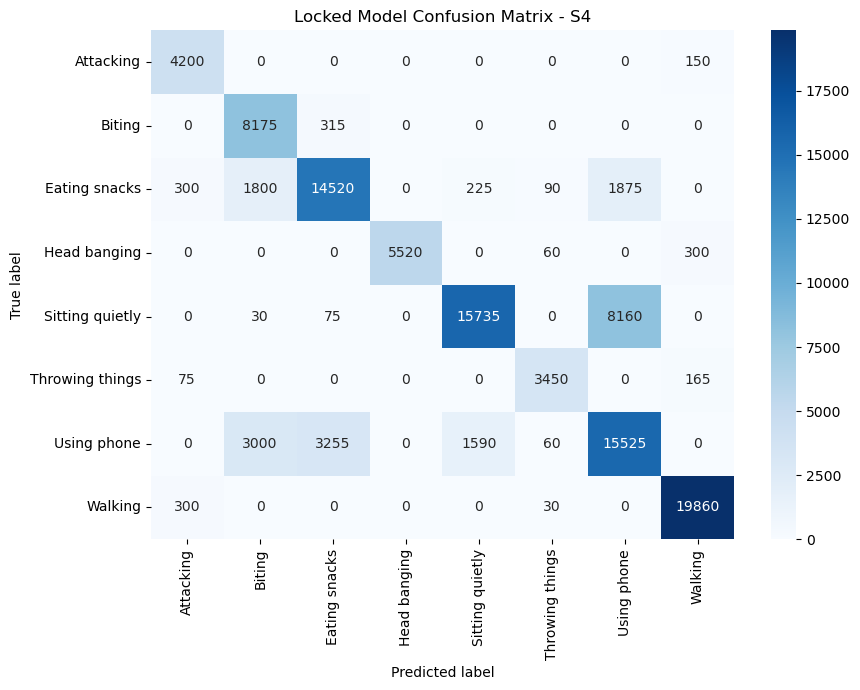

In [15]:
s4_metrics = json.loads((PHASE_DIR / 'locked_phase_d_s4_metrics.json').read_text())
display(pd.DataFrame([s4_metrics]))
display(pd.read_csv(PHASE_DIR / 'locked_phase_d_s4_top_confusions.csv').head(10))
show_fold('locked_phase_d_s4'.replace('_fold', ''), 4, 'S4 Confusion Matrix') if False else None
confusion_s4 = pd.read_csv(PHASE_DIR / 'locked_phase_d_s4_confusion.csv', index_col=0)
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_s4, annot=True, fmt='d', cmap='Blues')
plt.title('Locked Model Confusion Matrix - S4')
plt.xlabel('Predicted label'); plt.ylabel('True label'); plt.tight_layout(); plt.show()

## 7. Five-Subject LOSO After S4 Labels Are Available

### Five-Subject LOSO - Held-Out S1

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
0,1,0.577864,0.576914,0.877297,0.993816,0.785233


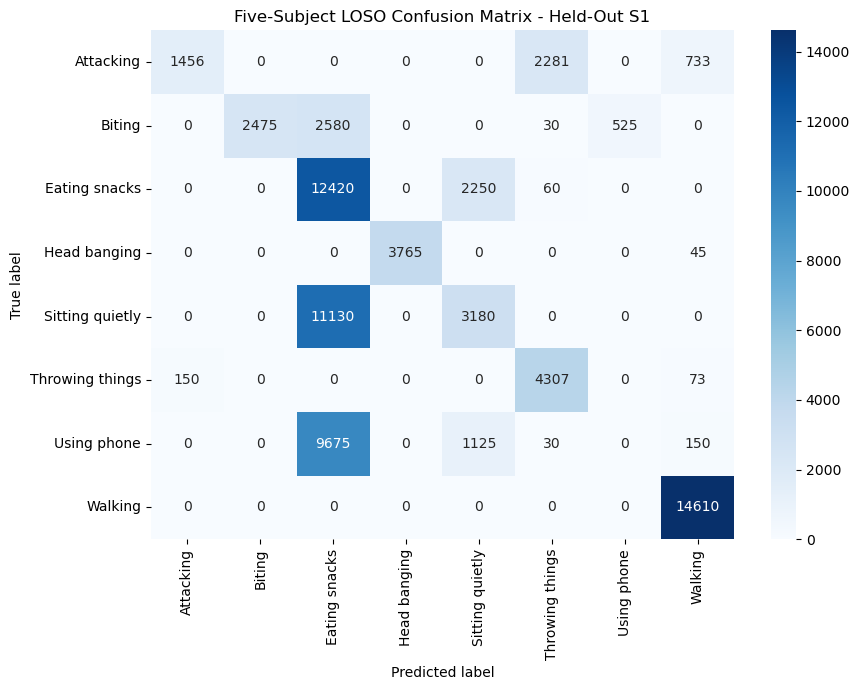

In [16]:
show_fold('five_subject', 1, 'Five-Subject LOSO Confusion Matrix - Held-Out S1')

### Five-Subject LOSO - Held-Out S2

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
1,2,0.741684,0.687774,0.871201,0.924258,0.823905


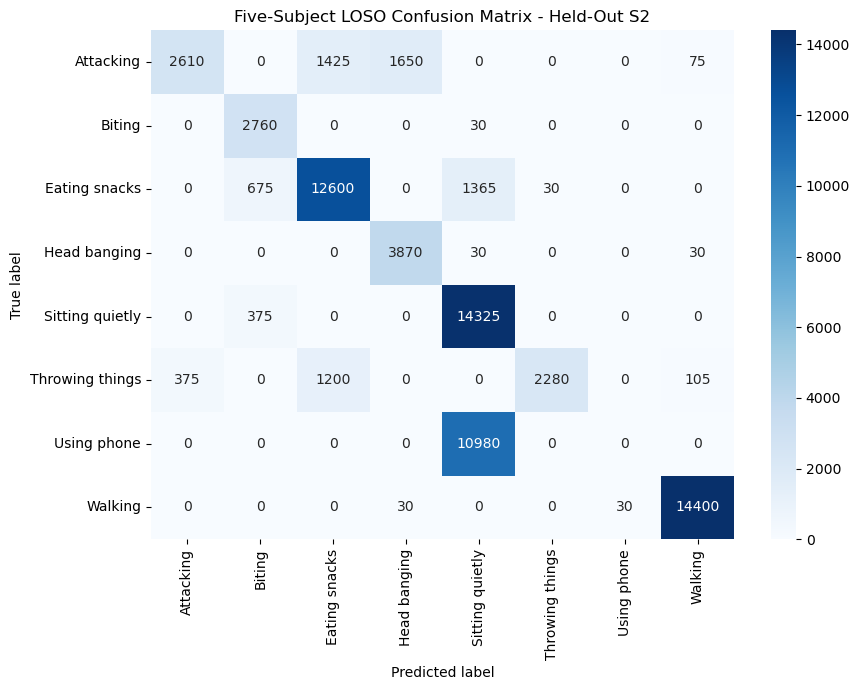

In [17]:
show_fold('five_subject', 2, 'Five-Subject LOSO Confusion Matrix - Held-Out S2')

### Five-Subject LOSO - Held-Out S3

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
2,3,0.788673,0.789149,0.866204,0.926502,0.813275


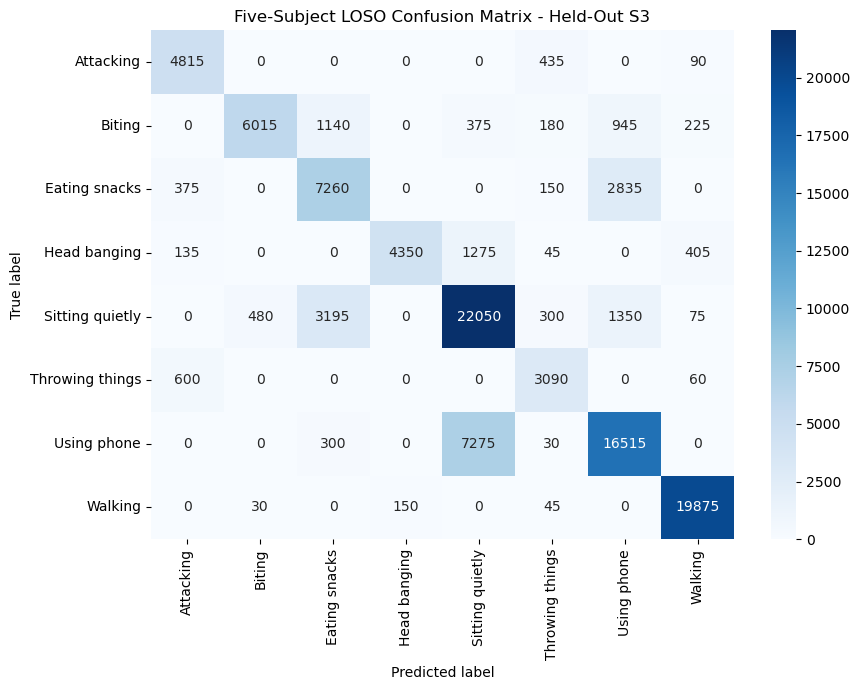

In [18]:
show_fold('five_subject', 3, 'Five-Subject LOSO Confusion Matrix - Held-Out S3')

### Five-Subject LOSO - Held-Out S4

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
3,4,0.816841,0.849487,0.876391,0.814007,0.94913


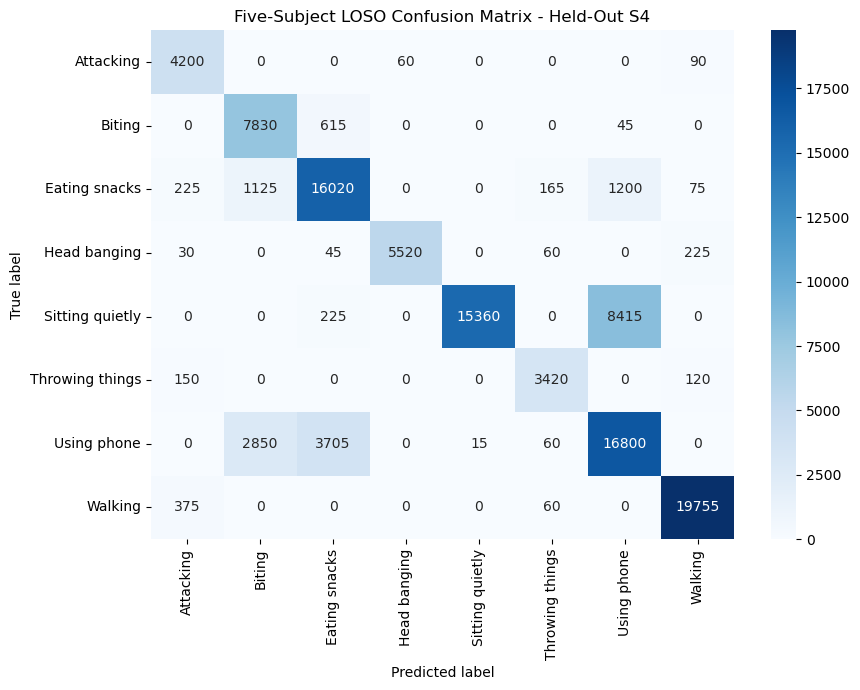

In [19]:
show_fold('five_subject', 4, 'Five-Subject LOSO Confusion Matrix - Held-Out S4')

### Five-Subject LOSO - Held-Out S5

,held_out_subject,accuracy,macro_f1,abnormal_f1,abnormal_precision,abnormal_recall
4,5,0.673141,0.715628,0.984241,0.987791,0.980716


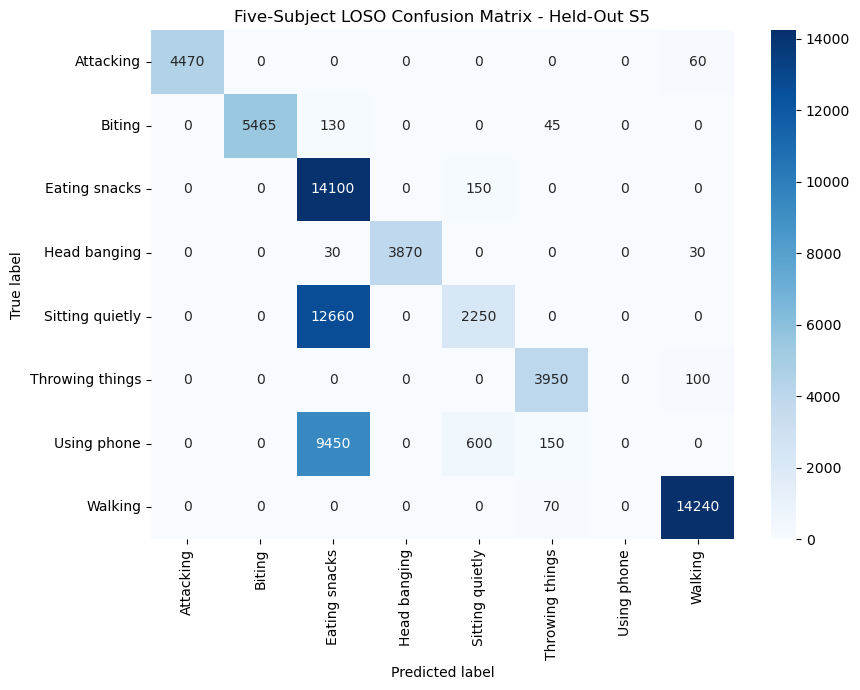

In [20]:
show_fold('five_subject', 5, 'Five-Subject LOSO Confusion Matrix - Held-Out S5')

## 8. Final All-Five Model Artifact

In [21]:
five_summary = json.loads((PHASE_DIR / 'five_subject_summary.json').read_text())
display(pd.DataFrame([five_summary]))
final_path = PHASE_DIR / 'final_phase_d_all_five_subjects.joblib'
final_model = joblib.load(final_path)
display(pd.DataFrame([{
    'artifact': str(final_path.resolve()),
    'size_mb': final_path.stat().st_size / 1024**2,
    'format_version': final_model['format_version'],
    'architecture': final_model['architecture'],
    'training_subjects': final_model['training_subjects'],
}]))

,method,pooled_accuracy,pooled_macro_f1,pooled_abnormal_f1,worst_subject_accuracy,worst_subject,config_locked_before_s4,transition_strength_locked_before_s4,method_reselected_after_s4
0,locked-D3-D1-five-subject-LOSO,0.733092,0.763901,0.893421,0.577864,1,"{'feature_budget': 256, 'learning_rate': 0.06,...",2.0,False


,artifact,size_mb,format_version,architecture,training_subjects
0,.\artifact...,2.622399,2,TSFEL-C + training-only selection + HistGradie...,"[1, 2, 3, 4, 5]"


## Deployment Note

The `.joblib` artifact is the reproducible desktop reference model. HistGradientBoosting and TSFEL are not directly executable on an ESP32. Embedded deployment therefore requires a separate feature-compatible lightweight model or generated C inference implementation, verified against this reference artifact on identical windows.